In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("multishapes-rei.csv")

# Preview data
print(df.head())
print(df.info())

          x         y
0 -0.129845  0.372790
1 -0.166034 -1.030413
2  0.427398 -0.931258
3  0.113308  0.431669
4  0.442206  0.174052
<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       900 non-null    float64
 1   y       900 non-null    float64
dtypes: float64(2)
memory usage: 14.2 KB
None


In [4]:
import pandas as pd

y_binned = pd.qcut(y, q=10, duplicates="drop")  # 10 quantile bins

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y_binned
)

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

R² Score: 0.4153704038035707
MSE: 3.3568426742186954


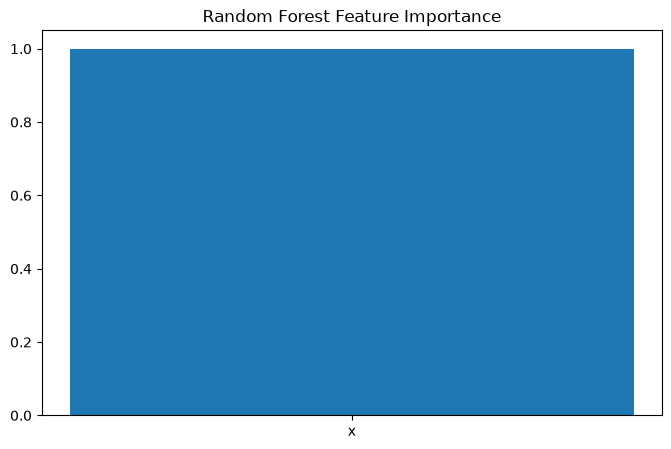

In [7]:
importances = rf_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8,5))
plt.bar(feature_names, importances)
plt.title("Random Forest Feature Importance")
plt.show()